# A-based clustering -> WU-based clustering of the remainder

Reproduces the two-stage clustering from `index_sqrt_wu_filter_20260701.ipynb` using the
functions in `scomv.gene_module`. The same fixed parameters as the original notebook are
used (`min_cluster_size` / weights / `method` / `A_THRESH`). In the original notebook, a
bug (multiplying by the weight before standardizing) meant that the `A_WEIGHT`/`B_WEIGHT`
values had effectively no effect; this bug is already fixed in `scomv.gene_module`, so
here the results are reproduced with the same numeric value (0.5) actually taking effect.

1. Cluster all genes by PCoA + inside/outside density ratio (A) and visualize the separation
2. Fix the clusters with high `mean_A` as "internal", then re-cluster the remaining genes
   by PCoA + uniformity (WU)
3. Merge internal + remaining


## 1. Setup

In [2]:
import scomv
import stlearn as st
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from adjustText import adjust_text

# NOTE: This notebook was run on an unpublished lung cancer Xenium panel dataset that is
# NOT included in this repository and is not publicly available. The data-loading and
# downstream cells below are kept commented out for reference only and cannot be executed
# as-is; supply your own Xenium output (cell_feature_matrix.h5 / cells.csv.gz) to reproduce
# this workflow on different data.

# # Load Xenium data using stlearn
# adata = st.ReadXenium(
#     feature_cell_matrix_file="./cell_feature_matrix.h5",
#     cell_summary_file="./cells.csv.gz",
#     library_id="example data",
#     image_path=None,
#     scale=1,
#     spot_diameter_fullres=10
# )
#
# sc.pp.filter_genes(adata, min_cells=300)
#
# N_COL = int((adata.obs.imagecol.max() - adata.obs.imagecol.min()) / 10)
# N_ROW = int((adata.obs.imagerow.max() - adata.obs.imagerow.min()) / 10)
# grid = st.tl.cci.grid(adata, n_row=N_ROW, n_col=N_COL, n_cpus=10, verbose=False)
#
# from scomv.preparation.skny_calc_distance import calculate_distance
#
# grid = calculate_distance(grid, pos_marker_ls=["CDH1"])
#
# sc.pp.filter_cells(adata, min_genes=10)
# print(adata)


[calculate_distance] N_ROW=564, N_COL=561, positive cells in grid=13535/316404
AnnData object with n_obs × n_vars = 132331 × 298
    obs: 'imagecol', 'imagerow', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial'


In [3]:
# Attach region / region_10 to grid.obs (referenced by extract_roi)
df_shotest = getattr(grid, "shortest")
df_grid = grid.to_df()

df_grid = pd.merge(
    pd.DataFrame(index=["grid_" + str(i + 1) for i in range(N_ROW * N_COL)]),
    df_grid, right_index=True, left_index=True, how="left",
).fillna(np.nan)

df_region = pd.DataFrame(
    np.array(df_shotest["region"]).reshape(N_ROW, N_COL).T.reshape(N_ROW * N_COL),
    index=["grid_" + str(i + 1) for i in range(N_ROW * N_COL)], columns=["region"],
)

df_grid_region = pd.merge(df_grid, df_region, right_index=True, left_index=True, how="left")
df_grid_region = df_grid_region.dropna()

grid.obs = pd.merge(grid.obs, df_grid_region[["region"]], right_index=True, left_index=True, how="left")

grid.obs["region_10"] = [str(i * 10) for i in grid.obs["region"]]
grid.obs["region_10"] = [
    "(" + str(int(float(i.split(", ")[0][1:]))) + ", " + str(int(float(i.split(", ")[-1][:-1]))) + "]"
    if i != "nan" else np.nan
    for i in grid.obs["region_10"]
]
grid.obs["region_10"] = grid.obs["region_10"].replace({"(-150, -120]": np.nan})


In [5]:
from scomv.gene_pipeline import SCOMVPipeline

gene_pipe = SCOMVPipeline(adata=adata, grid=grid, bin_size=10)
gene_out = gene_pipe.run(roi=(4450, 4850, 3650, 4150))

coords = gene_pipe.coords[["PC1", "PC2"]]
print(f"n selected genes: {len(gene_pipe.selected_genes)}")
coords.head()

n selected genes: 298


,PC1,PC2
ACE,0.181828,0.083073
ACE2,-0.100485,-0.129561
ACTA2,0.240447,0.069116
ADGRL4,0.288191,-0.088719
AGT,-0.238201,0.066315


## 2. Compute uniformity / inside-outside density ratio (A)


In [6]:
import math
from scomv.gene_module import compute_gene_uniformity
from scomv.tumor_solid import weighted_mean_across_bins
import importlib
import scomv.gene_module
importlib.reload(scomv.gene_module)
from scomv.gene_module import cluster_genes_by_pcoa

# Distance bins: 10-100µm. Weight = sqrt(15/d) (closer bins weighted more), n_ref=24.
ALL_DIST_BINS_G = {
    "10-20µm": (16, 15), "20-30µm": (17, 25), "30-40µm": (18, 35),
    "40-50µm": (19, 45), "50-60µm": (20, 55), "60-70µm": (21, 65),
    "70-80µm": (22, 75), "80-90µm": (23, 85), "90-100µm": (24, 95),
}
DIST_BINS_G = {k: idx for k, (idx, _) in ALL_DIST_BINS_G.items()}
BIN_WEIGHTS_G = {k: math.sqrt(15 / d) for k, (_, d) in ALL_DIST_BINS_G.items()}

wu_df = compute_gene_uniformity(
    gene_pipe.subset_grid, gene_pipe.selected_genes, gene_pipe.polar_counts_list,
    DIST_BINS_G, n_ref=24,
)
wu_score = weighted_mean_across_bins(wu_df, BIN_WEIGHTS_G)


In [7]:
from scomv.gene_module import compute_inside_outside_density_ratio

density_ratio = compute_inside_outside_density_ratio(
    gene_pipe.selected_genes, gene_pipe.polar_counts_list, gene_pipe.radius_bins,
    n_inside=len(gene_pipe.inside_points), n_total=len(gene_pipe.xy_list),
)
density_ratio.describe()

count    298.000000
mean       1.771928
std        1.623648
min        0.000000
25%        0.478648
50%        1.292415
75%        2.594558
max        8.375731
Name: density_ratio, dtype: float64

## 3. Stage 1 — Cluster all genes by PCoA + A

`min_cluster_size=12`, `A_WEIGHT=0.5`, `method="eom"`, `epsilon=0.0` — same fixed values as the original notebook.


In [71]:
from scomv.gene_module import cluster_genes_by_pcoa

MIN_CLUSTER_SIZE = 12
A_WEIGHT = 0.3

labels_a, cluster_info_a = cluster_genes_by_pcoa(
    coords,
    extra_axes={"mean_A": (density_ratio, A_WEIGHT)},
    min_cluster_size=MIN_CLUSTER_SIZE,
    cluster_selection_method="leaf",
    cluster_selection_epsilon=0.0,
)

print(f"n clusters: {len(cluster_info_a)}  (min_cluster_size={MIN_CLUSTER_SIZE})")
print(f"{'cluster':<8}{'n':>5}{'mean_A':>10}")
for cid, info in cluster_info_a.items():
    print(f"C{cid:<7}{info['n']:>5}{info['mean_A']:>10.3f}")

n clusters: 9  (min_cluster_size=12)
cluster     n    mean_A
C0         44     4.681
C1         38     2.349
C2         68     1.986
C3         20     1.606
C4         35     0.770
C5         28     0.618
C6         22     0.460
C7         20     0.336
C8         23     0.198


## 4. Fix internal clusters (mean_A ≥ A_THRESH)

`A_THRESH` is a substantive threshold on the density ratio itself (how much denser the
inside is than the outside), not something to be tuned by looking at how the genes split.


In [72]:
A_THRESH = 1.2

internal_summary = {cid: info for cid, info in cluster_info_a.items() if info["mean_A"] >= A_THRESH}
internal_genes = set(g for info in internal_summary.values() for g in info["genes"])
remaining_genes = [g for g in coords.index if g not in internal_genes and g in wu_score.index]

print(f"internal clusters: {len(internal_summary)}  (genes: {len(internal_genes)})")
print(f"remaining genes: {len(remaining_genes)}")

internal clusters: 4  (genes: 170)
remaining genes: 128


### Stage 1 visualization (only internal clusters colored, everything else as gray background)


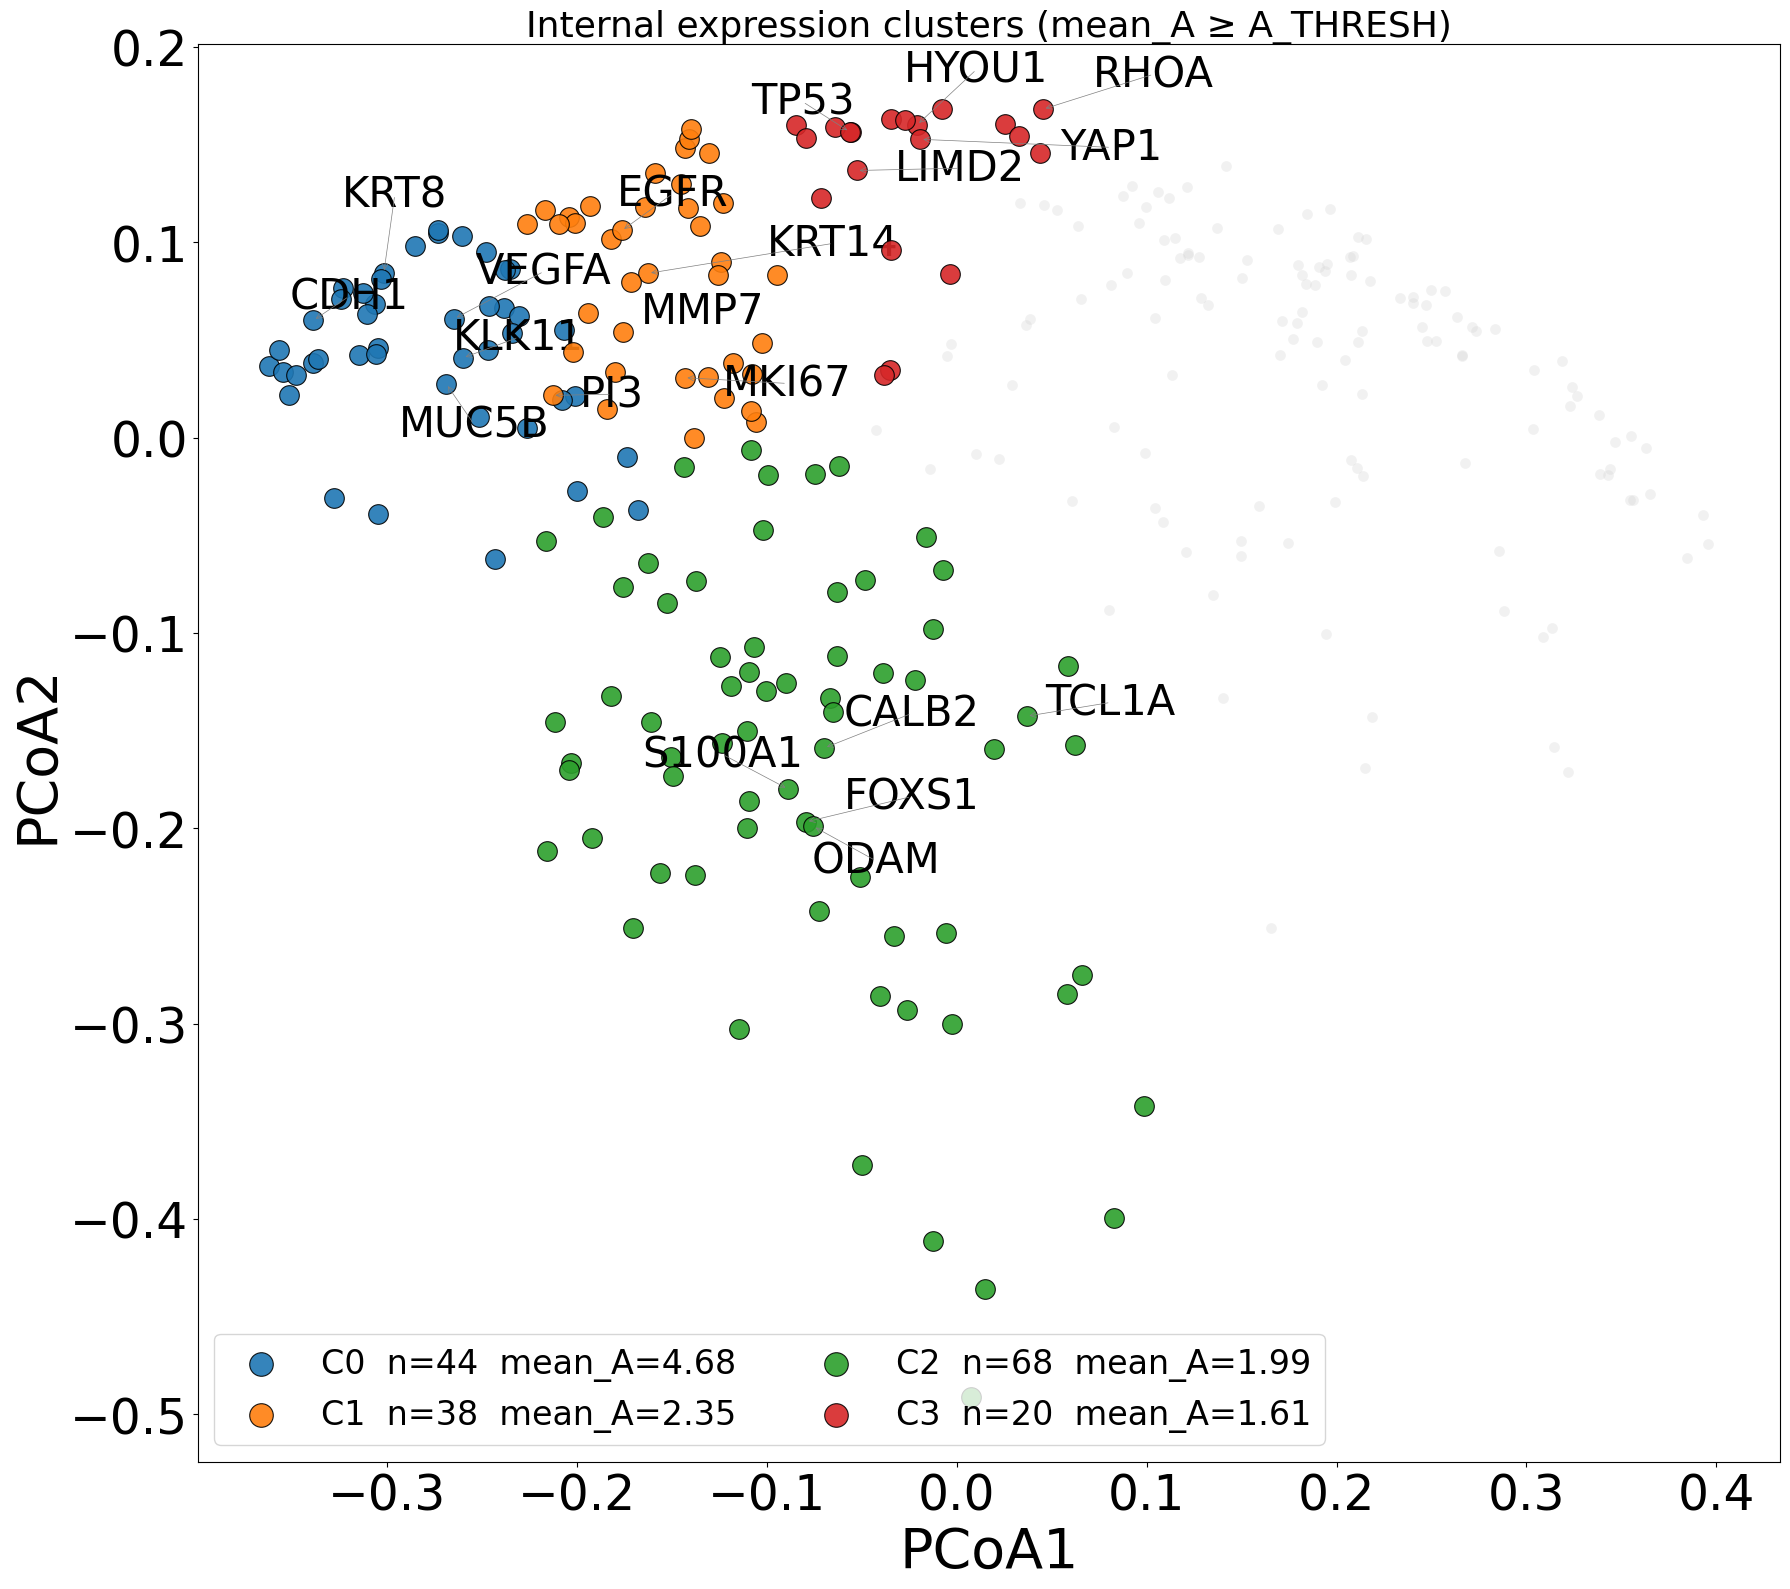

In [73]:
from scomv.gene_module import select_cluster_annotation_genes

t_cells     = {"CD3D", "CD3E", "CD4", "CD247", "CD8A", "GZMA", "TRAC"}
b_cells     = {"CD19", "BANK1", "MS4A1", "TCL1A", "CD79A"}
macrophage  = {"CD68", "CD80", "CD86", "CD163"}
epithelial  = {"CDH1", "EPCAM", "KRT8"}
endothelial = {"CD93", "PECAM1", "VWF"}
fibroblast  = {"POSTN", "LUM", "MMP2"}
focus    = {"PLVAP", "RHOA", "SMAD6", "TP53", "VEGFA", "MKI67", "ADGRL4", "RGS5",
            "PI3", "CAV1", "EGFR", "AQP3", "C15orf48", "MMP12", "CXCL9", "CXCL13"}

marker_genes = t_cells | b_cells | macrophage | epithelial | endothelial | fibroblast | focus

def plot_highlighted_clusters(highlight_summary, background_genes, title, value_key, value_label):
    """Colors only the clusters in highlight_summary; background_genes are drawn as gray
    background points. Annotates at least 5 genes per cluster, preferring marker_genes and
    filling in with genes near the centroid."""
    cluster_annot = select_cluster_annotation_genes(
        highlight_summary, coords, preset_genes=marker_genes, min_annotations=5,
    )
    cmap = plt.cm.tab10.colors
    fig, ax = plt.subplots(figsize=(18, 16), dpi=100)

    bg_x = [coords.loc[g, "PC1"] for g in background_genes]
    bg_y = [coords.loc[g, "PC2"] for g in background_genes]
    ax.scatter(bg_x, bg_y, color="lightgray", s=60, alpha=0.3, linewidths=0, zorder=1)

    texts = []
    for i, (cid, info) in enumerate(highlight_summary.items()):
        color = cmap[i % len(cmap)]
        genes_c = info["genes"]
        xs = [coords.loc[g, "PC1"] for g in genes_c]
        ys = [coords.loc[g, "PC2"] for g in genes_c]
        ax.scatter(xs, ys, color=color, s=200, alpha=0.9, edgecolors="black", linewidths=0.8, zorder=3,
                   label=f"C{cid}  n={info['n']}  {value_label}={info[value_key]:.2f}")
        for g in genes_c:
            if g in cluster_annot[cid]:
                texts.append(ax.text(coords.loc[g, "PC1"], coords.loc[g, "PC2"], g, fontsize=30, color="black"))

    adjust_text(
        texts, ax=ax,
        arrowprops=dict(arrowstyle="->", color="gray", lw=0.5),
        only_move={"points": "xy", "text": "xy"},
        force_text=1.5, force_points=1.0,
        expand_text=(1.2, 1.2), expand_points=(1.2, 1.2),
        lim=200, precision=0.01, autoalign="y",
    )
    ax.set_xlabel("PCoA1", fontsize=40); ax.set_ylabel("PCoA2", fontsize=40)
    ax.tick_params(labelsize=35)
    ax.set_title(title, fontsize=26)
    ax.legend(fontsize=24, markerscale=1.2, ncol=2, loc="best")
    plt.tight_layout()
    plt.show()

background_genes_stage1 = [g for g in coords.index if g not in internal_genes]
plot_highlighted_clusters(
    internal_summary, background_genes_stage1,
    "Internal expression clusters (mean_A ≥ A_THRESH)",
    value_key="mean_A", value_label="mean_A",
)

## 5. Stage 2 — Re-cluster the remainder by WU

`min_cluster_size=10`, `B_WEIGHT=0.5`, `method="eom"`, `epsilon=0.0` — same fixed values as the original notebook.


In [74]:
MIN_CLUSTER_SIZE_R = 10
B_WEIGHT = 0.5

labels_wu, remaining_summary = cluster_genes_by_pcoa(
    coords,
    extra_axes={"mean_wu": (wu_score, B_WEIGHT)},
    genes=remaining_genes,
    min_cluster_size=MIN_CLUSTER_SIZE_R,
    cluster_selection_method="leaf",
    cluster_selection_epsilon=0.1,
)

print(f"n clusters: {len(remaining_summary)}  (min_cluster_size={MIN_CLUSTER_SIZE_R})")
print(f"{'cluster':<8}{'n':>5}{'mean_wu':>10}")
for cid, info in remaining_summary.items():
    print(f"C{cid:<7}{info['n']:>5}{info['mean_wu']:>10.3f}")

n clusters: 6  (min_cluster_size=10)
cluster     n   mean_wu
C0         31     0.419
C1         28     0.146
C2         12     0.349
C3         16     0.585
C4         16     0.595
C5         25     0.527


### Stage 2 visualization (only remaining clusters colored, internal as gray background)


Combined clusters: 10
  C1 [internal]  n=44  mean_A=4.68
  C2 [internal]  n=38  mean_A=2.35
  C3 [internal]  n=68  mean_A=1.99
  C4 [internal]  n=20  mean_A=1.61
  C5 [remaining]  n=31  mean_wu=0.419
  C6 [remaining]  n=28  mean_wu=0.146
  C7 [remaining]  n=12  mean_wu=0.349
  C8 [remaining]  n=16  mean_wu=0.585
  C9 [remaining]  n=16  mean_wu=0.595
  C10 [remaining]  n=25  mean_wu=0.527


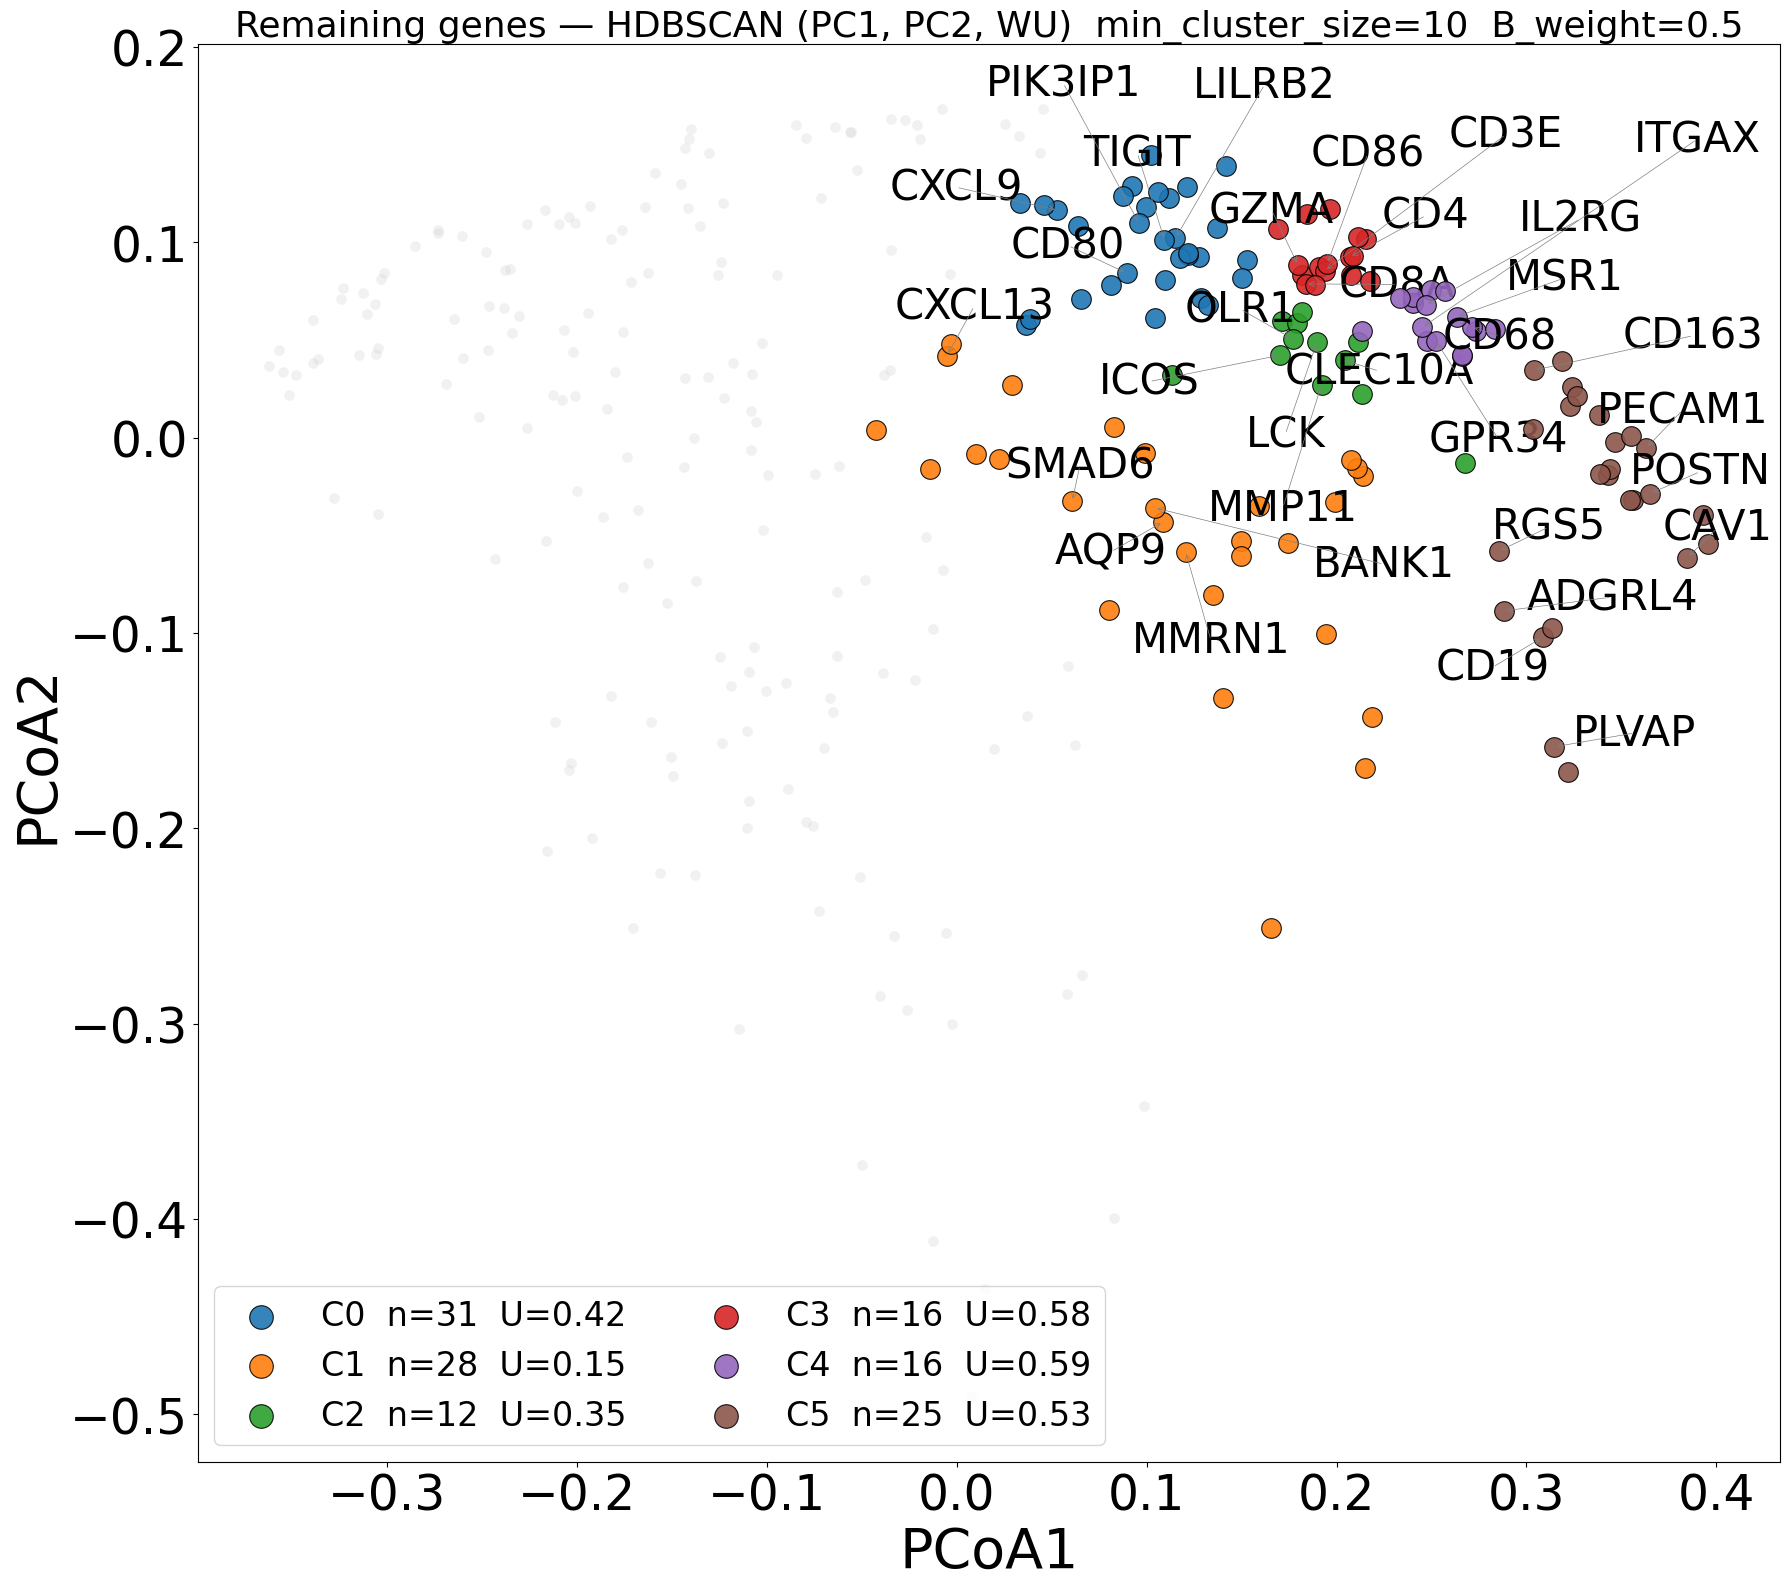

In [75]:
from scomv.gene_module import combine_cluster_summaries

unified = combine_cluster_summaries(("internal", internal_summary), ("remaining", remaining_summary))
print(f"Combined clusters: {len(unified)}")
for num, info in unified.items():
    score = f"mean_A={info['mean_A']:.2f}" if info["source"] == "internal" else f"mean_wu={info['mean_wu']:.3f}"
    print(f"  C{num} [{info['source']}]  n={info['n']}  {score}")

plot_highlighted_clusters(
    remaining_summary, list(internal_genes),
    f"Remaining genes — HDBSCAN (PC1, PC2, WU)  min_cluster_size={MIN_CLUSTER_SIZE_R}  B_weight={B_WEIGHT}",
    value_key="mean_wu", value_label="U",
)

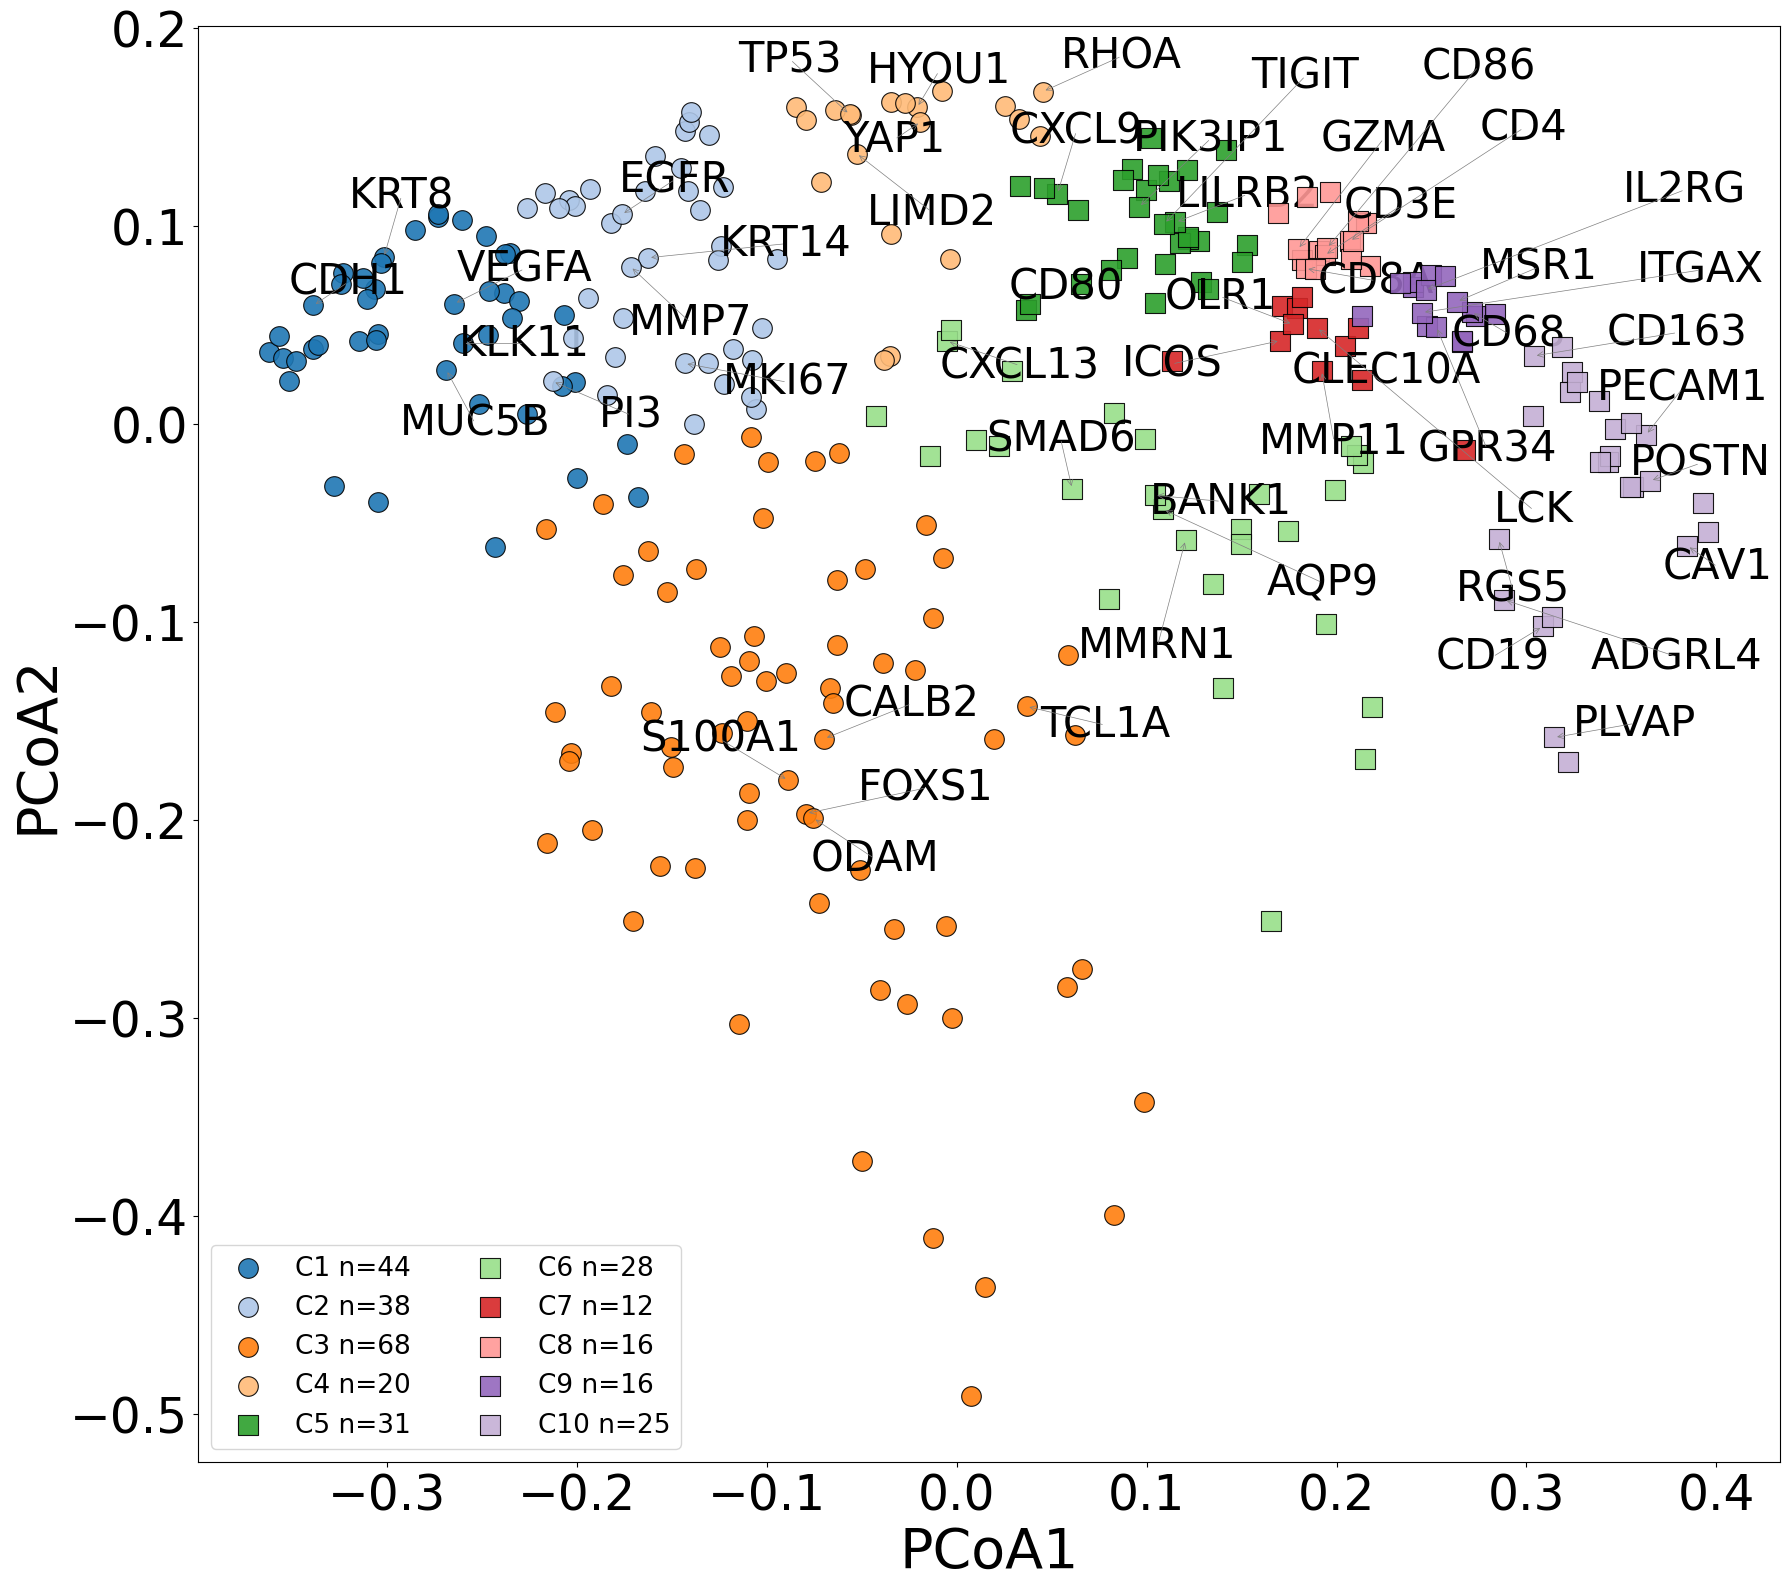

In [76]:
# Overall clustering result (internal + remaining, all colored together)
cluster_annot_all = select_cluster_annotation_genes(unified, coords, preset_genes=marker_genes, min_annotations=5)

cmap_combined = plt.cm.tab20.colors
fig, ax = plt.subplots(figsize=(18, 16), dpi=100)

texts = []
for i, (num, info) in enumerate(unified.items()):
    color = cmap_combined[i % len(cmap_combined)]
    genes_c = info["genes"]
    xs = [coords.loc[g, "PC1"] for g in genes_c]
    ys = [coords.loc[g, "PC2"] for g in genes_c]
    mkr = "o" if info["source"] == "internal" else "s"
    ax.scatter(xs, ys, color=color, s=200, alpha=0.9, edgecolors="black", linewidths=0.8, zorder=3,
               marker=mkr, label=f"C{num} n={info['n']}")
    for g in genes_c:
        if g in cluster_annot_all[num]:
            texts.append(ax.text(coords.loc[g, "PC1"], coords.loc[g, "PC2"], g, fontsize=30, color="black"))

classified = set(g for info in unified.values() for g in info["genes"])
unclassified = [g for g in coords.index if g not in classified]
ux = [coords.loc[g, "PC1"] for g in unclassified]
uy = [coords.loc[g, "PC2"] for g in unclassified]
ax.scatter(ux, uy, color="lightgray", s=60, alpha=0.3, linewidths=0, zorder=1)

adjust_text(
    texts, ax=ax,
    arrowprops=dict(arrowstyle="->", color="gray", lw=0.5),
    only_move={"points": "xy", "text": "xy"},
    force_text=1.5, force_points=1.0,
    expand_text=(1.2, 1.2), expand_points=(1.2, 1.2),
    lim=200, precision=0.01, autoalign="y",
)
ax.set_xlabel("PCoA1", fontsize=40); ax.set_ylabel("PCoA2", fontsize=40)
ax.tick_params(labelsize=35)
#ax.set_title("Combined clustering result", fontsize=26)
ax.legend(fontsize=19, markerscale=1.0, ncol=2, loc="best")
plt.tight_layout()
plt.show()

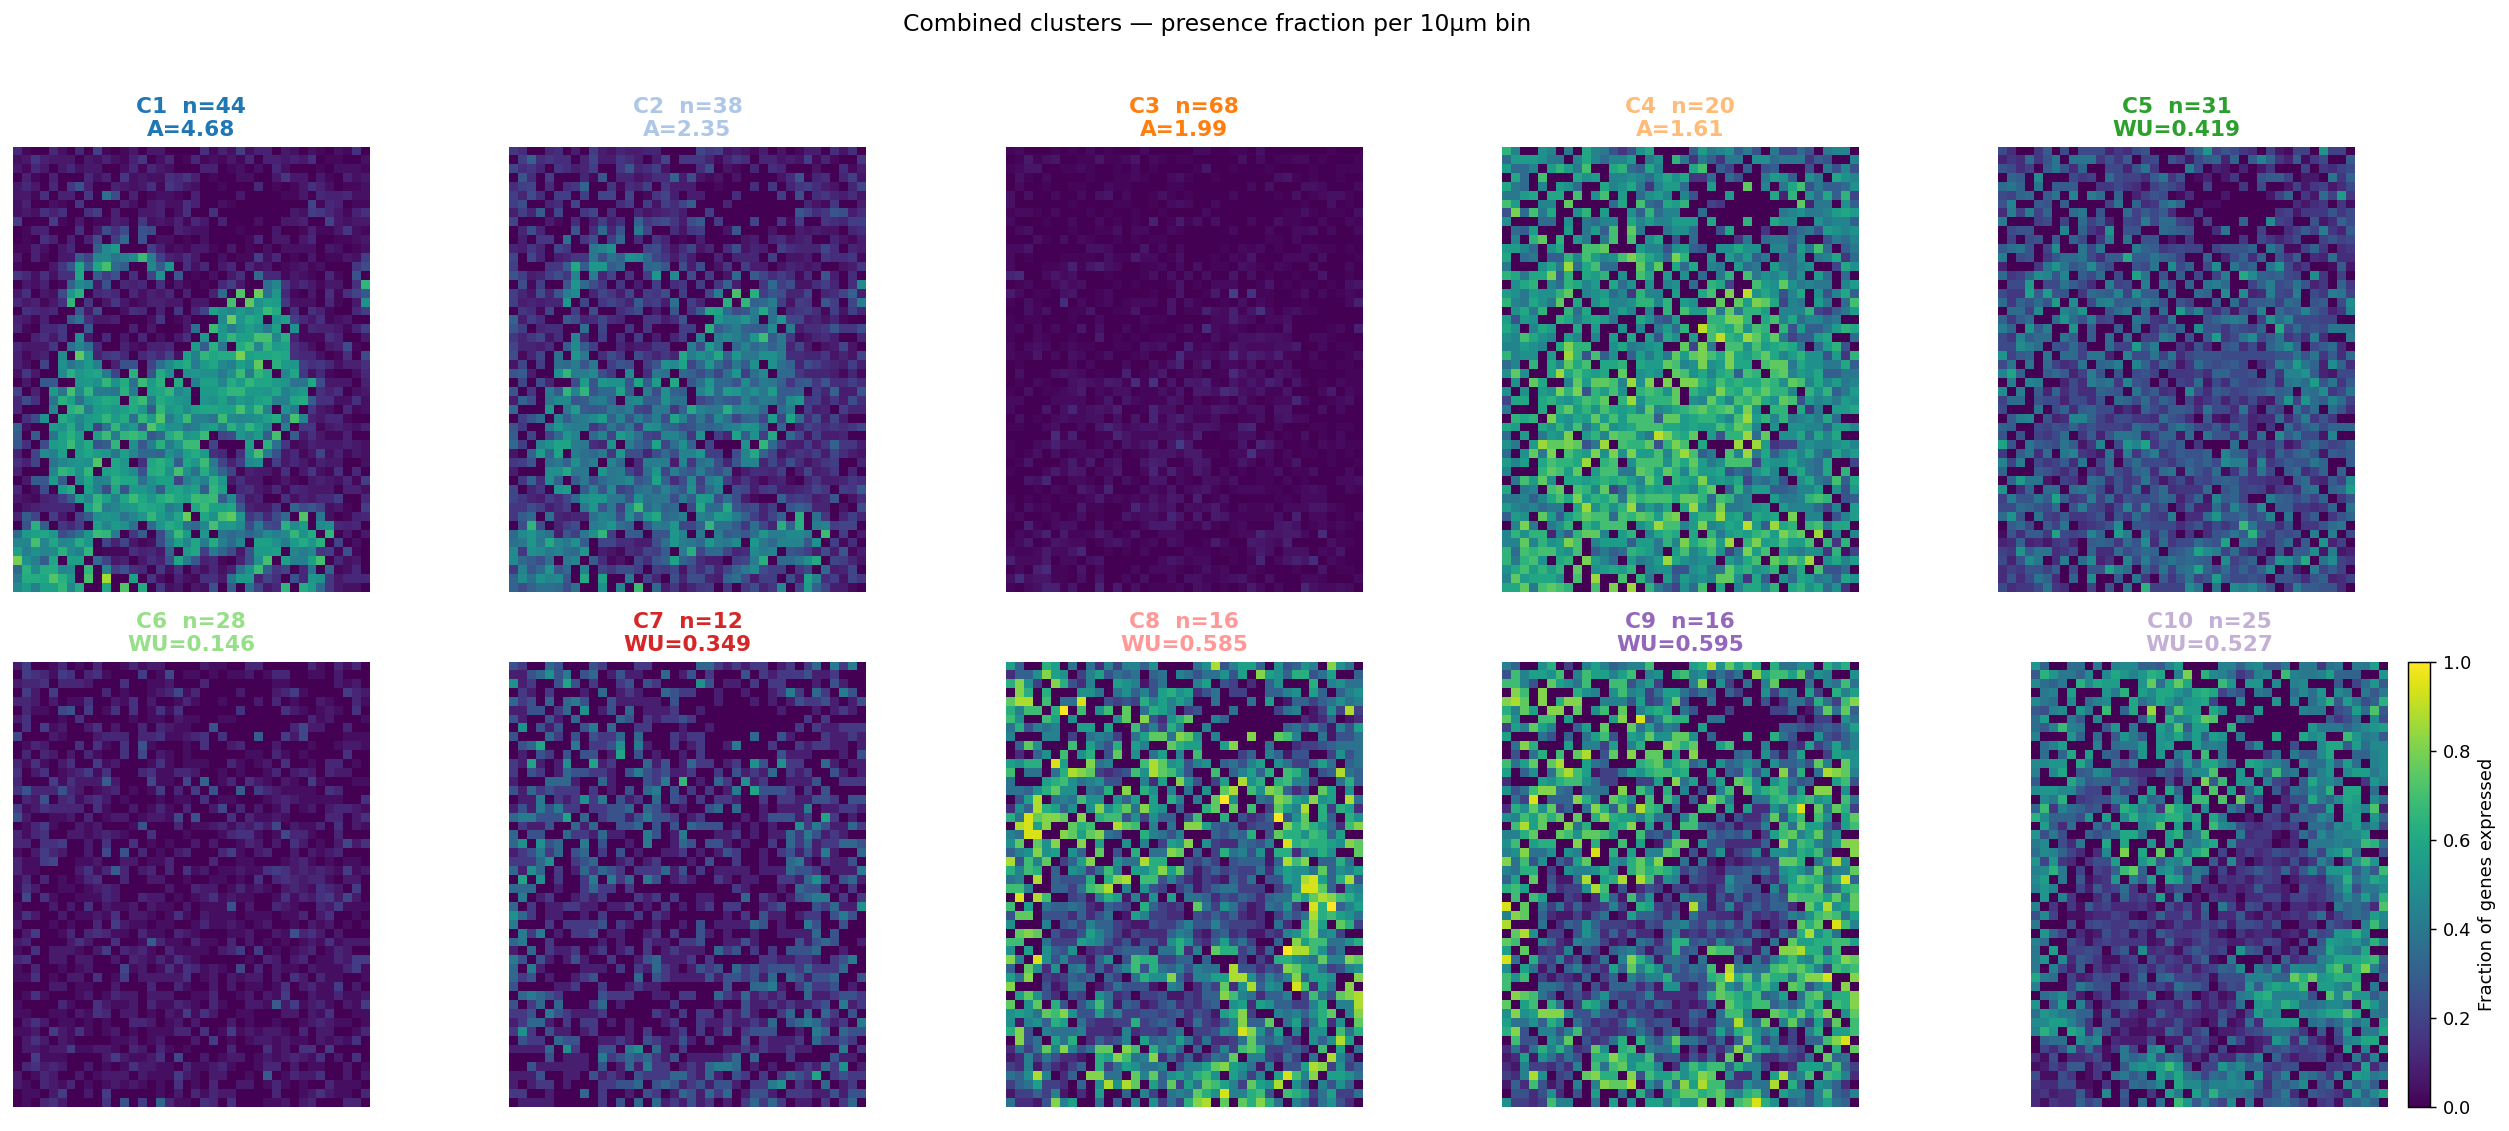

In [77]:
# Presence fraction for all clusters × 10µm bins
from scomv.gene_module import compute_presence_fraction_map, plot_presence_fraction_grid

pres_maps = {}
pres_colors = {}
for i, (num, info) in enumerate(unified.items()):
    score = f"A={info['mean_A']:.2f}" if info["source"] == "internal" else f"WU={info['mean_wu']:.3f}"
    label = f"C{num}  n={info['n']}\n{score}"
    pres_maps[label] = compute_presence_fraction_map(gene_pipe.subset_grid, info["genes"], bin_size_um=10)
    pres_colors[label] = cmap_combined[i % len(cmap_combined)]

fig = plot_presence_fraction_grid(
    pres_maps, colors=pres_colors, max_cols=5,
    suptitle="Combined clusters — presence fraction per 10µm bin",
)
plt.show()

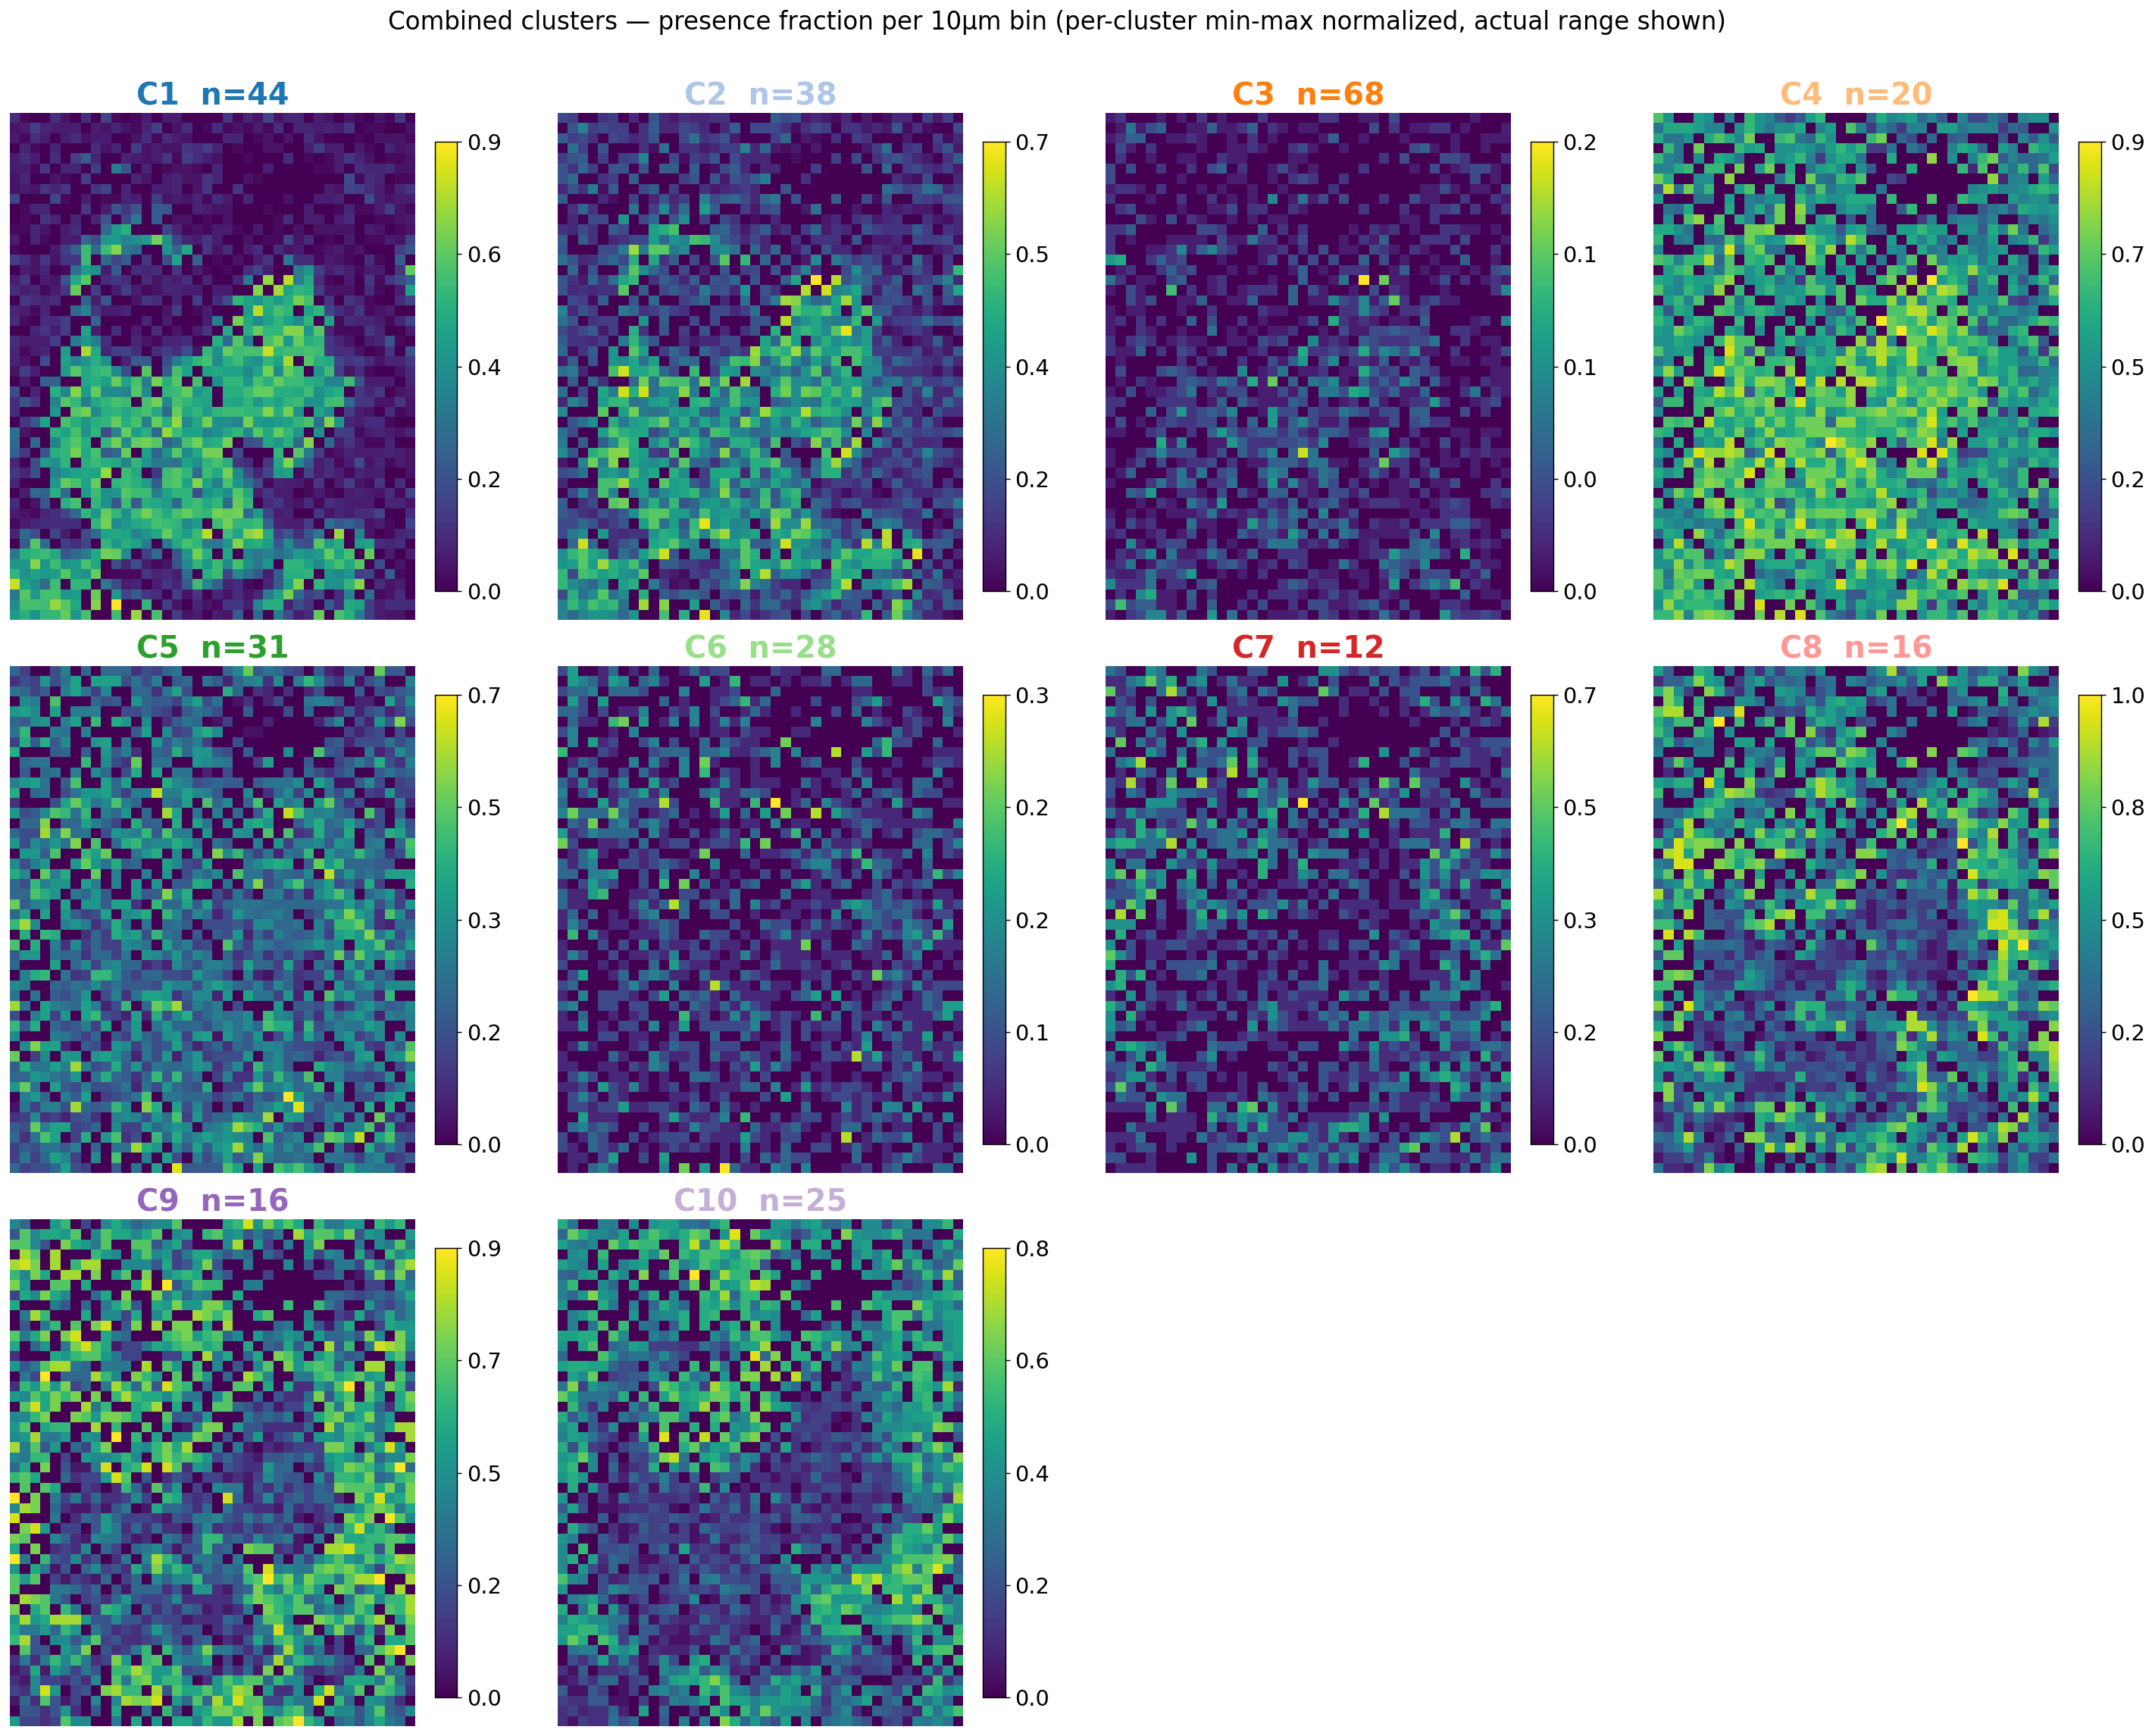

In [78]:
# Presence fraction for all clusters × 10µm bins (min-max normalized independently per
# cluster; colorbar ticks show that cluster's actual value range)
n = len(pres_maps)
n_cols = 4
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.6 * n_cols, 5.8 * n_rows), dpi=130,
                          sharex=True, sharey=True, squeeze=False)

tick_positions = np.linspace(0, 1, 5)

for i, (label, m) in enumerate(pres_maps.items()):
    row, col = divmod(i, n_cols)
    ax = axes[row][col]
    lo, hi = m.min(), m.max()
    m_norm = (m - lo) / (hi - lo) if hi > lo else np.zeros_like(m)

    im = ax.imshow(m_norm, cmap="viridis", aspect="equal", origin="upper",
                    vmin=0, vmax=1, interpolation="nearest")
    title = label.split("\n")[0]
    ax.set_title(title, fontsize=22, fontweight="bold", color=pres_colors[label])
    ax.axis("off")

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, ticks=tick_positions)
    cbar.ax.set_yticklabels([f"{lo + t * (hi - lo):.1f}" for t in tick_positions])
    cbar.ax.tick_params(labelsize=16)

for i in range(n, n_rows * n_cols):
    row, col = divmod(i, n_cols)
    axes[row][col].axis("off")

fig.suptitle("Combined clusters — presence fraction per 10µm bin (per-cluster min-max normalized, actual range shown)",
             fontsize=18, y=1.01)
fig.tight_layout()
plt.show()

## 6. GO enrichment (background restricted to this panel's genes, optional)


In [79]:
from scomv.gene_module import run_go_enrichment_per_cluster, plot_go_enrichment_per_cluster

cluster_genes_for_go = {f"C{num}": info["genes"] for num, info in unified.items()}
background_genes_go = list(coords.index)

go_results = run_go_enrichment_per_cluster(
    cluster_genes_for_go,
    background_genes=background_genes_go,
    gene_sets=["GO_Biological_Process_2023", "GO_Molecular_Function_2023"],
)
n_with_hits = sum(not df.empty for df in go_results.values())
print(f"{n_with_hits} / {len(go_results)} clusters have at least one significant GO term")

2 / 10 clusters have at least one significant GO term


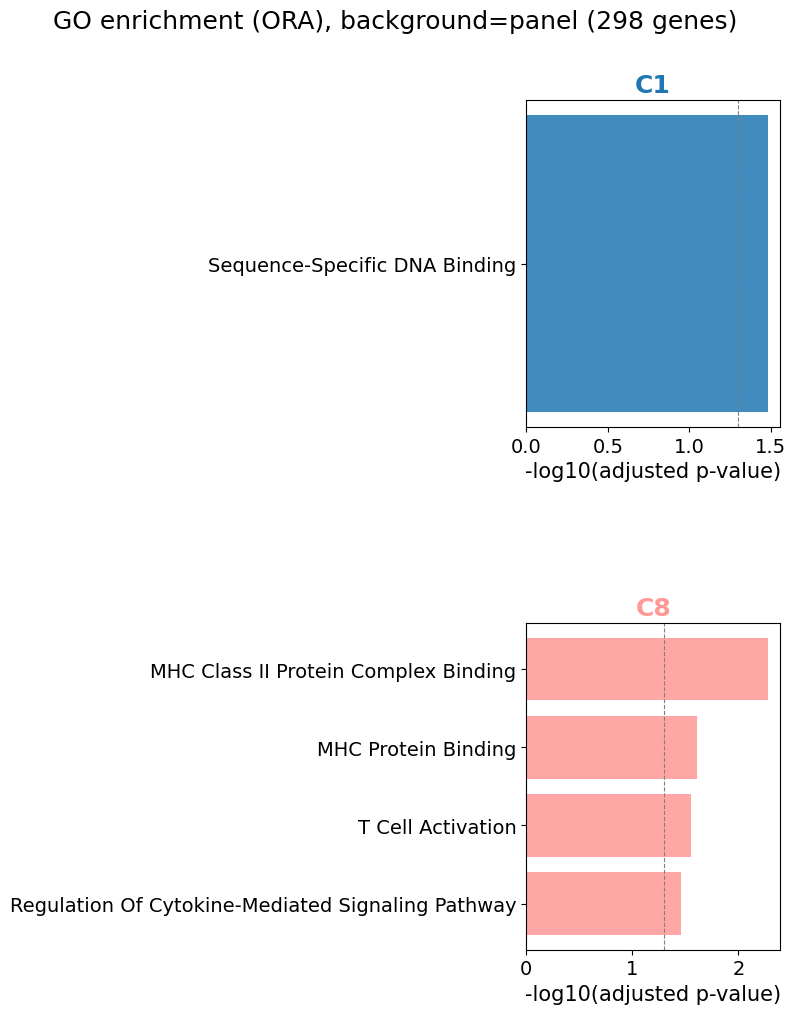

In [80]:
go_colors = {f"C{num}": cmap_combined[i % len(cmap_combined)] for i, (num, info) in enumerate(unified.items())}

fig = plot_go_enrichment_per_cluster(
    go_results, top_n=5, n_cols=1,
    colors=go_colors,
    suptitle=f"GO enrichment (ORA), background=panel ({len(background_genes_go)} genes)",
)
if fig is not None:
    plt.show()
else:
    print("No significant GO terms found.")

In [81]:
go_results_nobg = run_go_enrichment_per_cluster(
    cluster_genes_for_go,
    background_genes=None,
    gene_sets=["GO_Biological_Process_2023", "GO_Molecular_Function_2023"],
)
n_with_hits_nobg = sum(not df.empty for df in go_results_nobg.values())
print(f"{n_with_hits_nobg} / {len(go_results_nobg)} clusters have at least one significant GO term")

10 / 10 clusters have at least one significant GO term


/Users/nomura/SpatialCompassV_2/src/scomv/gene_module.py:1013: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


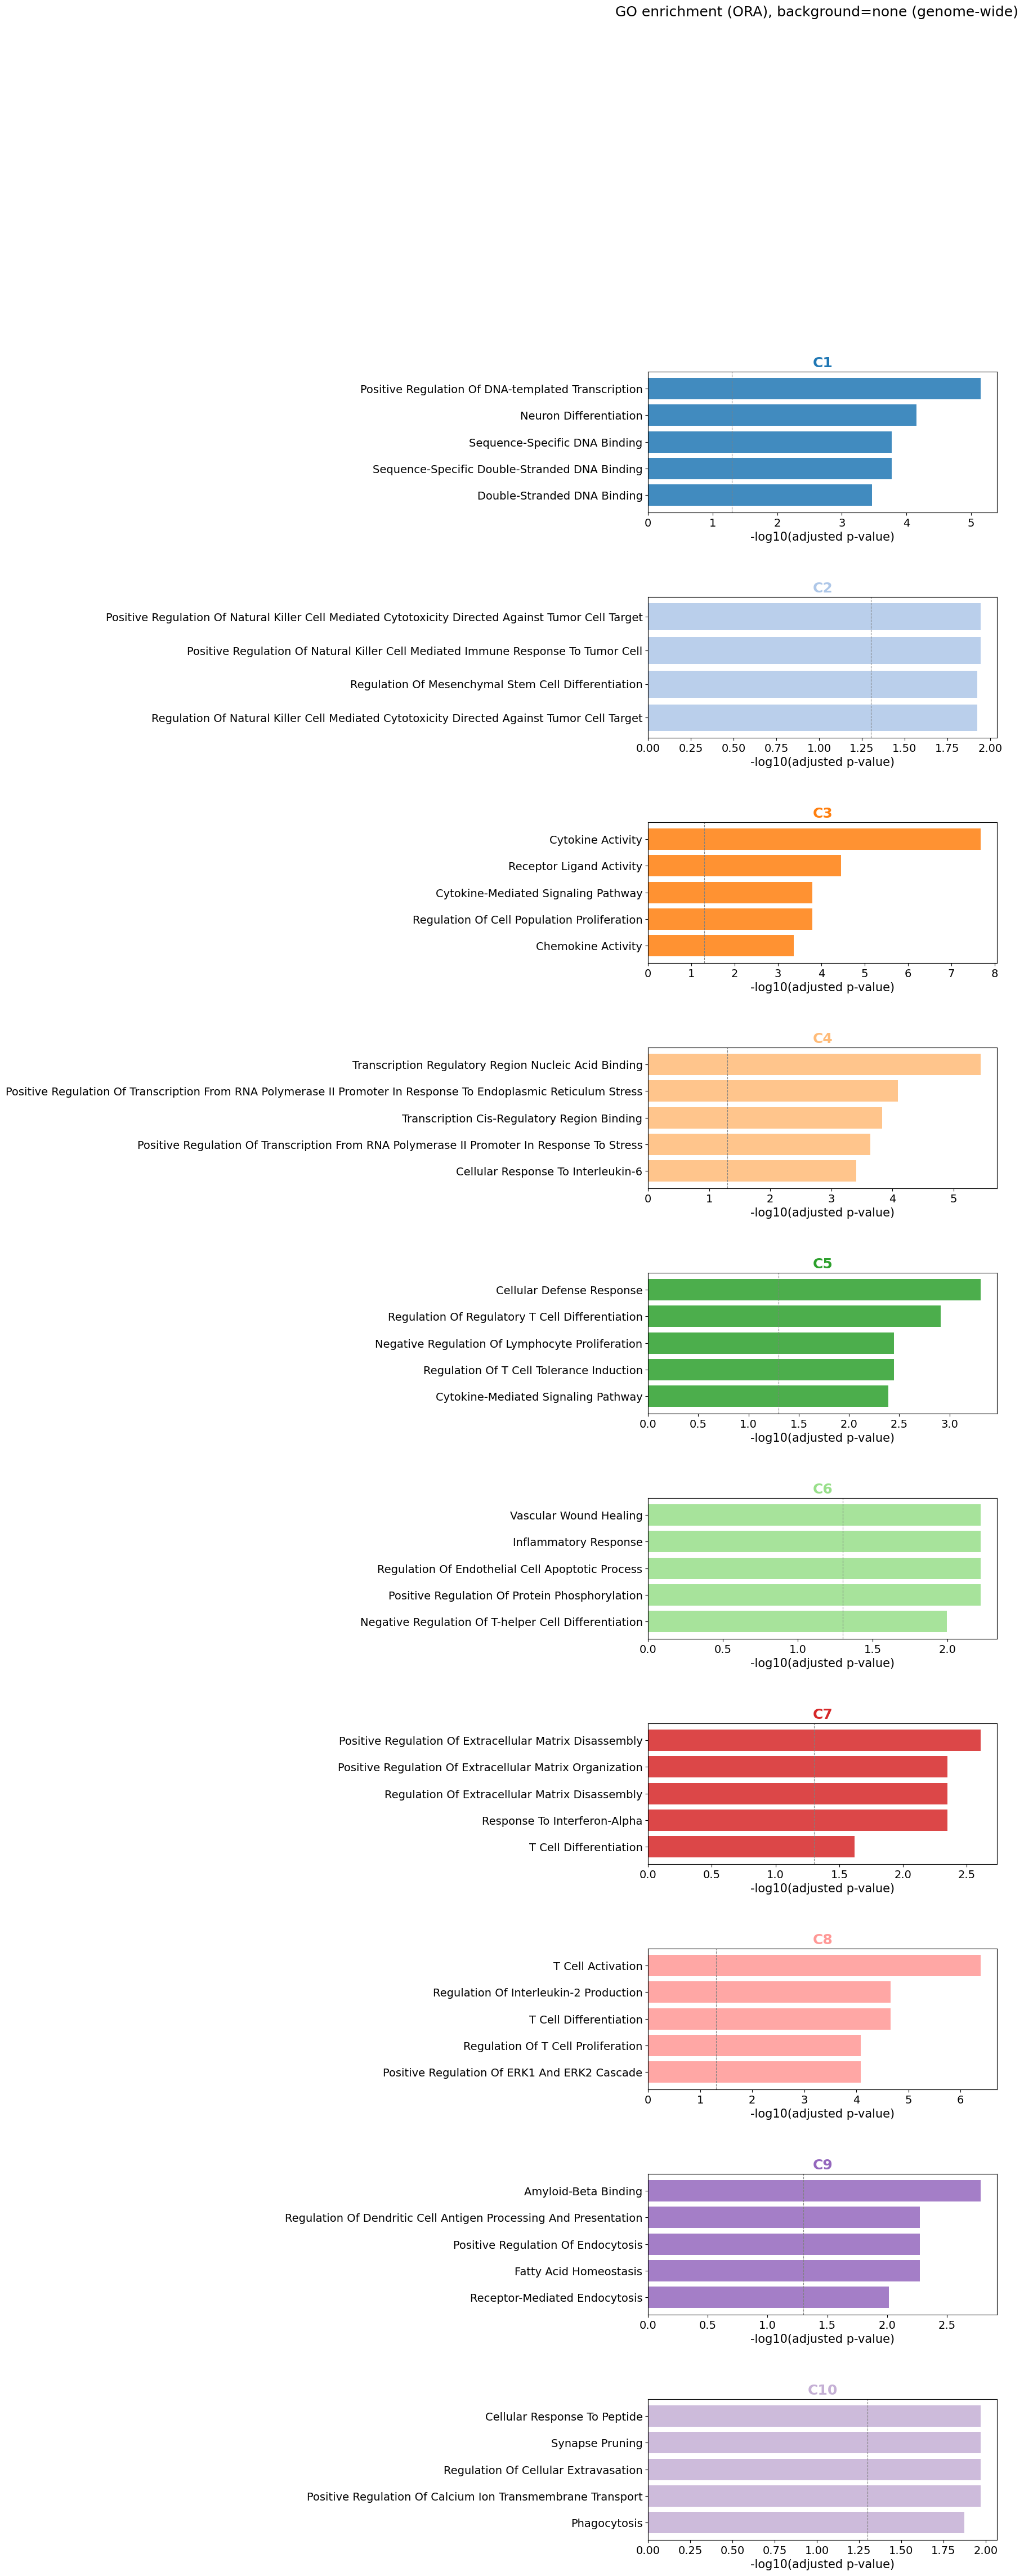

In [82]:
fig = plot_go_enrichment_per_cluster(
    go_results_nobg, top_n=5, n_cols=1,
    colors=go_colors,
    suptitle="GO enrichment (ORA), background=none (genome-wide)",
)
if fig is not None:
    plt.show()
else:
    print("No significant GO terms found.")

In [87]:
from scomv.plot_3d import plot_3d
import plotly.io as pio

fig = plot_3d(
    adata=gene_out["subset_grid"],
    genes=("POSTN", "CD3E"),
    anchor_gene="CDH1",
    bin_size=10,
    x_range=(4450, 4850),
    y_range=(3650, 4150),
    height_scale=3,
    anchor_scale=1,
    threshold=4,
    sigma=1.0,
)
pio.renderers.default = "notebook_connected"
fig.show()


CD3E: n=1642


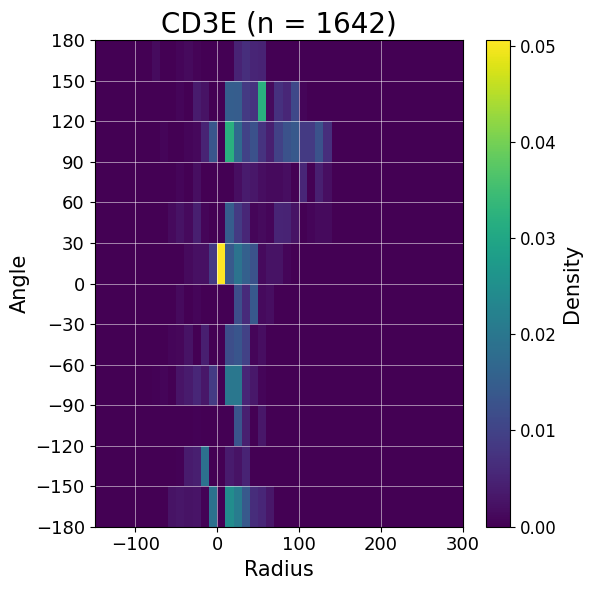

In [86]:
from scomv.polar_slice_viewer import plot_polar_slice_interactive
from scomv.gene_view_tool import plot_gene_polar_hist2d, plot_2d_expression

A_counts, _, _ = plot_gene_polar_hist2d(
    subset_grid=gene_pipe.subset_grid,
    min_vector_df=gene_pipe.min_vector_df,
    gene="CD3E",
)

POSTN: n=2734


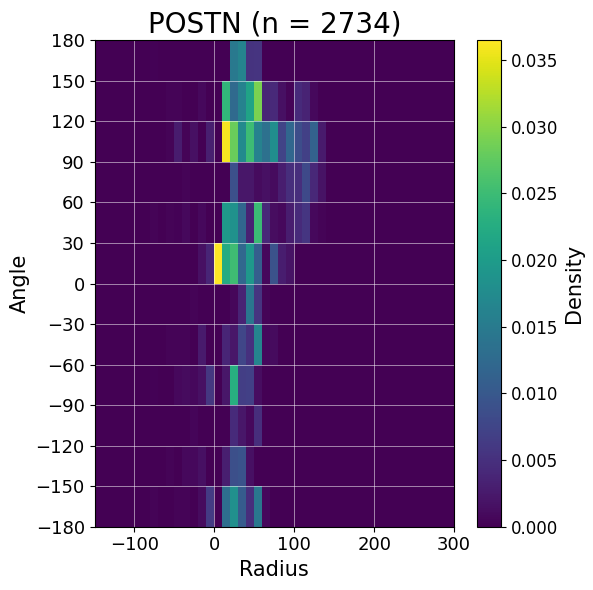

In [88]:
A_counts, _, _ = plot_gene_polar_hist2d(
    subset_grid=gene_pipe.subset_grid,
    min_vector_df=gene_pipe.min_vector_df,
    gene="POSTN",
)

Please specify a valid `library_id` or set it permanently in `adata.uns['spatial']`


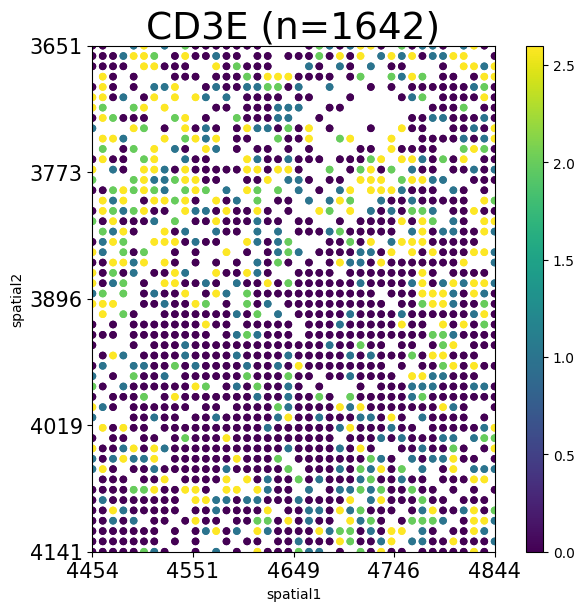

Please specify a valid `library_id` or set it permanently in `adata.uns['spatial']`


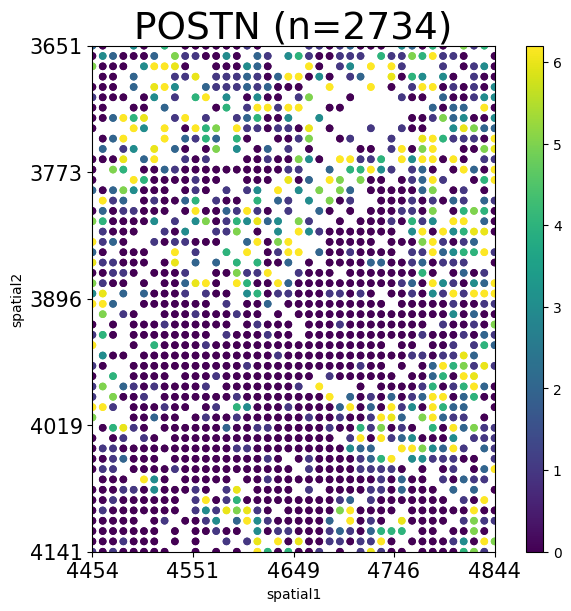

In [90]:
## Draw 2D pictures
gs = ["CD3E", "POSTN"] # the genes you want to draw
for g in gs:
    plot_2d_expression(g, subset_grid)